In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Employee_Attrition.csv')
df.head()

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0


In [3]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [4]:
df=df.drop('Employee_ID',axis=1)
df.head()

,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,56,31395,18,HR,Poor,Yes,1,7,School,1
2,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,39,20851,5,HR,Good,No,2,7,Graduate,0
4,28,32156,12,Developer,Good,No,3,26,School,0


In [5]:
df=pd.get_dummies(df,drop_first=True)
df.sample(5)

,Age,Monthly_Income,Years_at_Company,Job_Satisfaction,Distance_From_Home,Attrition,Job_Role_Developer,Job_Role_HR,Job_Role_Manager,Work_Life_Balance_Good,Work_Life_Balance_Poor,Overtime_Yes,Education_Postgraduate,Education_School
249,38,99963,15,3,8,0,False,False,True,False,True,False,False,False
206,50,70678,10,3,30,0,False,False,True,True,False,False,True,False
171,44,115339,20,2,9,1,False,False,True,False,True,True,False,True
69,48,90545,17,3,14,0,False,False,True,True,False,True,False,False
121,49,32903,20,3,29,0,True,False,False,True,False,True,False,True


In [6]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['Attrition'])
y=df['Attrition']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((200, 13), (50, 13), (200,), (50,))

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
k=[]
for i in range(1,26):
    nn=KNeighborsClassifier(i)
    model=nn.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acuracyscore=accuracy_score(y_test,y_pred)
    k.append(acuracyscore)

In [9]:
k

[0.86,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94]

In [10]:
print(k.index(max(k))+1)

2


In [11]:
k[2]

0.94

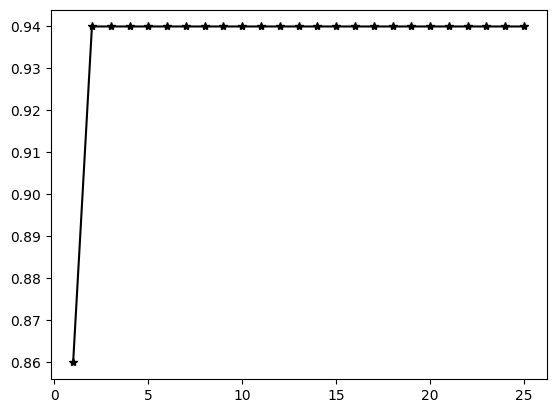

In [12]:
import matplotlib.pyplot as plt
plt.plot(list(range(1,26)),k,'-*k')
plt.show()

#### k=2 is most accurate

In [13]:
bestn=KNeighborsClassifier(2)
model=bestn.fit(x_train,y_train)
model

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
model.predict([[30,45000,5,3,10,True,False,False,True,False,True,False,0,]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

# With Random forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=5)
rf

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred=rf.predict(x_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])